In [32]:
# Import pandas library
import pandas as pd

In [33]:
# Get the `moviecast.zip` into a dataframe
df = pd.read_csv('data/moviecast.zip',sep='|')

In [34]:
# Take a quick look
df.head()

,name,title,year,rating,votes
0,Ève Francis,Spanish Fiesta,2019,6.9,29
1,Gabriel Gabrio,Spanish Fiesta,2019,6.9,29
2,Jean Toulout,Spanish Fiesta,2019,6.9,29
3,Gaston Modot,Spanish Fiesta,2019,6.9,29
4,Antonio Cañero,La tierra de los toros,2000,5.4,14


### Indexing methods

- `.set_index('column_name')`
- `.loc(label)`
-`.iloc(positions)`
- `.reset_index()`

In [35]:
# Using .loc with set_index()
df = df.set_index('title')

In [36]:
# Selecting some rows and columns using .loc()
df.loc['The Karate Kid',['name','rating']]

,name,rating
title,,
The Karate Kid,Ralph Macchio,7.3
The Karate Kid,Pat Morita,7.3
The Karate Kid,Elisabeth Shue,7.3
The Karate Kid,Martin Kove,7.3
The Karate Kid,Jackie Chan,6.2
The Karate Kid,Jaden Smith,6.2
The Karate Kid,Taraji P. Henson,6.2
The Karate Kid,Wenwen Han,6.2


In [37]:
df = df.reset_index()
# Setting a multiindex
df = df.set_index(['title','year'])

In [38]:
df.loc[('The Karate Kid',1984)]

/tmp/ipykernel_59/1678053336.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df.loc[('The Karate Kid',1984)]


name  rating   votes
title          year                                
The Karate Kid 1984   Ralph Macchio     7.3  209089
               1984      Pat Morita     7.3  209089
               1984  Elisabeth Shue     7.3  209089
               1984     Martin Kove     7.3  209089

In [39]:
# Resetting the index
df = df.reset_index('year')
df = df.reset_index('title')

## Groupby operations

`df.groupby()`

`.size()` - gives counts

`.mean()` - gives mean of a column of numerical data

`.max(),min()` - max, min values for the given column

In [40]:
# Selecting movies starred by Leonardo DiCaprio
leo = df[df.name=='Leonardo DiCaprio']

In [41]:
# Taking a quick look
df.head()

,title,year,name,rating,votes
0,Spanish Fiesta,2019,Ève Francis,6.9,29
1,Spanish Fiesta,2019,Gabriel Gabrio,6.9,29
2,Spanish Fiesta,2019,Jean Toulout,6.9,29
3,Spanish Fiesta,2019,Gaston Modot,6.9,29
4,La tierra de los toros,2000,Antonio Cañero,5.4,14


In [42]:
# Find the average rating of all Leo's movies
leo.rating.mean()

7.302777777777777

## Groupby method

In [43]:
# Using groupby to get the mean ratings across movies
leo.groupby(df.year)['rating'].mean()

year
1993    7.500000
1995    6.766667
1996    6.700000
1997    7.800000
1998    6.400000
2000    6.700000
2001    5.700000
2002    7.800000
2004    7.500000
2006    8.250000
2007    7.200000
2008    7.166667
2009    4.800000
2010    7.975000
2011    6.500000
2012    7.900000
2013    7.700000
2015    8.000000
2016    8.200000
2017    7.200000
2019    7.550000
Name: rating, dtype: float64

In [44]:
# Grouping by columns that are not present
leo.groupby(df.year//10*10)['rating'].mean()

year
1990    6.930000
2000    7.125000
2010    7.721429
Name: rating, dtype: float64

## `.merge()`

- Can be used to combine two different datasets

In [45]:
# We load a new dataframe which has movie release dates
rd = pd.read_csv('data/release_dates.zip',parse_dates=['date'])

In [46]:
# Use .merge here on the  'title' and 'year' columns
dateleo = leo.merge(rd,on=['title','year'])

<AxesSubplot:>

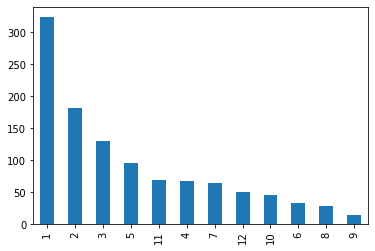

In [47]:
# Plot to get the months in which movies by Leonardo DiCaprio were released
dateleo.date.dt.month.value_counts(ascending=False).plot(kind='bar')

### Who all have co-starred with Leonardo ? 

- To answer this question, we'd have to merge `leo` with `cast.csv` itself

In [48]:
# Merge operation can be done on the same dataframe
costars = leo.drop(columns=['rating','votes']).merge(df.drop(columns = ['rating','votes']),on=['title','year'])                            

In [49]:
# Surprise, surprise, Leonardo has co-starred Leonardo in every movie he's in!
# So we drop where Leonardo appears in the co-star
costars = costars[costars.name_y !='Leonardo DiCaprio']

In [51]:
costars.groupby('name_y').size().sort_values(ascending=False)[:10]

name_y
Kate Winslet      3
Russell Crowe     2
Robert De Niro    2
Matt Damon        2
Tobey Maguire     2
Billy Zane        2
Margot Robbie     2
Jack Nicholson    2
Mark Wahlberg     1
Mark Strong       1
dtype: int64

### Saving your work

After you are done with your analysis, you can save your dataframe to a `.csv` file with the `df.to_csv(filename)` command.

Other formats are supported as well.

In [55]:
# Saving to a csv file
costars.to_csv('leonardo_costars.csv',index=False)

In [56]:
# Let's load our saved data again
df = pd.read_csv('leonardo_costars.csv')
df.head()

,title,year,name_x,name_y
0,This Boy's Life,1993,Leonardo DiCaprio,Robert De Niro
1,This Boy's Life,1993,Leonardo DiCaprio,Ellen Barkin
2,This Boy's Life,1993,Leonardo DiCaprio,Jonah Blechman
3,What's Eating Gilbert Grape,1993,Leonardo DiCaprio,Johnny Depp
4,What's Eating Gilbert Grape,1993,Leonardo DiCaprio,Juliette Lewis


# FIN